In [1]:
from pathlib import Path
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
!ls

analysis_results.ipynb				results      results.zip
data						results.csv  scripts
q_tensor_best_fibernet_config_high_density.qmd	results_XX


In [3]:
from pathlib import Path
import json
import re
import pandas as pd

broad = {
    "densities": [8, 16, 24, 32],
    "lambda_tvas": [0.0, 1e-11, 1e-9, 1e-6, 1e-5],
    "learning_rates": [1e-3, 5e-4, 1e-4],
    "models": ["alpha", "q_alpha", "q_direct"],
    "n_iter": 30000,
}

# Robustly find the results folder
possible_results_dirs = [
    Path("results"),
    Path.cwd() / "results",
]

RESULTS_DIR = None
for p in possible_results_dirs:
    if p.exists() and p.is_dir():
        RESULTS_DIR = p
        break

if RESULTS_DIR is None:
    matches = list(Path.cwd().rglob("results"))
    matches = [m for m in matches if m.is_dir() and any(m.glob("density*"))]
    if not matches:
        raise FileNotFoundError("Could not find a results/ directory containing density* folders.")
    RESULTS_DIR = matches[0]

print("Using RESULTS_DIR:", RESULTS_DIR.resolve())


def decode_token(raw: str) -> float:
    """
    Handles tokens like:
      0          -> 0.0
      1em06      -> 1e-06
      1em05      -> 1e-05
      0p001      -> 0.001
      0p0005     -> 0.0005
    """
    raw = raw.strip()
    raw = raw.replace("p", ".")
    raw = re.sub(r"(\d+)em(\d+)", r"\1e-\2", raw)
    return float(raw)


def flatten_json(obj, prefix=""):
    """
    Flatten dicts.
    Lists are kept as lists, and also expanded into indexed columns.
    """
    out = {}

    if isinstance(obj, dict):
        for k, v in obj.items():
            key = f"{prefix}.{k}" if prefix else str(k)
            out.update(flatten_json(v, key))

    elif isinstance(obj, list):
        out[prefix] = obj
        for i, v in enumerate(obj):
            key = f"{prefix}_{i}"
            if isinstance(v, dict):
                out.update(flatten_json(v, key))
            else:
                out[key] = v

    else:
        out[prefix] = obj

    return out


def parse_metadata_from_path(json_path: Path) -> dict:
    parts = json_path.relative_to(RESULTS_DIR).parts

    meta = {
        "density": None,
        "lambda_tva": None,
        "learning_rate": None,
        "n_iter": None,
        "batch_size": None,
        "model": None,
        "json_kind": json_path.stem,
        "json_file": json_path.name,
        "path": str(json_path),
    }

    for part in parts:
        if part.startswith("density"):
            meta["density"] = int(part.removeprefix("density"))

        elif part.startswith("lambda_tva"):
            meta["lambda_tva"] = decode_token(part.removeprefix("lambda_tva"))

        elif part.startswith("lr"):
            meta["learning_rate"] = decode_token(part.removeprefix("lr"))

        elif part.startswith("niter"):
            meta["n_iter"] = int(part.removeprefix("niter"))

        elif part.startswith("batch"):
            meta["batch_size"] = int(part.removeprefix("batch"))

        elif part in broad["models"]:
            meta["model"] = part

    return meta


rows = []

for json_path in sorted(RESULTS_DIR.rglob("*.json")):
    if json_path.stem in ["config", "summary"]:
        continue
    try:
        with open(json_path, "r") as f:
            payload = json.load(f)

        meta = parse_metadata_from_path(json_path)
        flat = flatten_json(payload)

        rows.append({**meta, **flat})

    except Exception as e:
        rows.append({
            "path": str(json_path),
            "json_file": json_path.name,
            "json_kind": json_path.stem,
            "parse_error": repr(e),
        })

df_json = pd.DataFrame(rows)

sort_cols = [
    "density",
    "lambda_tva",
    "learning_rate",
    "n_iter",
    "batch_size",
    "model",
    "json_kind",
]
sort_cols = [c for c in sort_cols if c in df_json.columns]

df_json = df_json.sort_values(sort_cols).reset_index(drop=True)

print("Parsed JSON files:", len(df_json))
df_json.head()

Using RESULTS_DIR: /home/theapparatus/Desktop/Universidad/2026-1/Taller de Ing/Repofinal/Experiments/delta-fibernet-experiments/experiments/q_tensor_best_fibernet_config_high_density/results
Parsed JSON files: 165


,density,lambda_tva,learning_rate,n_iter,batch_size,model,json_kind,json_file,path,angular_error_deg_mean,...,final_loss_pde,final_loss_regu_orient,final_loss_regu_orient_weighted,train_time_seconds,train_time_minutes,train_iters_requested,train_iters_completed,checkpoint_dir,checkpoint_resumed,checkpoint_resumed_from_iter
0,8,0.0,0.001,50000,32,alpha,metrics,metrics.json,results/density8/lambda_tva0/lr0p001/niter5000...,28.815609,...,0.022276,0.911075,0.0,600.549408,10.009157,50000,50000,/home/qpinns/Experiments/delta-fibernet-experi...,False,0
1,8,0.0,0.001,50000,32,q_alpha,metrics,metrics.json,results/density8/lambda_tva0/lr0p001/niter5000...,28.815609,...,0.022276,1.734749,0.0,601.117665,10.018628,50000,50000,/home/qpinns/Experiments/delta-fibernet-experi...,False,0
2,8,0.0,0.001,50000,32,q_direct,metrics,metrics.json,results/density8/lambda_tva0/lr0p001/niter5000...,24.675606,...,0.072154,0.699095,0.0,601.908040,10.031801,50000,50000,/home/qpinns/Experiments/delta-fibernet-experi...,False,0
3,8,0.0,0.001,100000,32,alpha,metrics,metrics.json,results/density8/lambda_tva0/lr0p001/niter1000...,19.444241,...,0.017275,1.161933,0.0,599.003212,9.983387,100000,100000,/home/qpinns/Experiments/delta-fibernet-experi...,True,50000
4,8,0.0,0.001,100000,32,q_alpha,metrics,metrics.json,results/density8/lambda_tva0/lr0p001/niter1000...,19.444241,...,0.017275,1.934706,0.0,599.986003,9.999767,100000,100000,/home/qpinns/Experiments/delta-fibernet-experi...,True,50000


In [4]:
df_metrics = df_json[df_json["json_kind"] == "metrics"].copy()

print("Metrics rows:", len(df_metrics))

df_stats = df_metrics[[
    "density",
    "lambda_tva",
    "learning_rate",
    "n_iter",
    "batch_size",
    "model",
    "angular_error_deg_mean",
    "angular_error_deg_median",
    "angular_error_deg_p25",
    "angular_error_deg_p75",
    "angular_error_deg_p95",
    "activation_observed_rmse_mean",
    "final_loss",
    "train_time_seconds",
    "train_time_minutes",
    "path",
]].copy()

Metrics rows: 165


In [5]:
df_stats

,density,lambda_tva,learning_rate,n_iter,batch_size,model,angular_error_deg_mean,angular_error_deg_median,angular_error_deg_p25,angular_error_deg_p75,angular_error_deg_p95,activation_observed_rmse_mean,final_loss,train_time_seconds,train_time_minutes,path
0,8,0.000000e+00,0.001,50000,32,alpha,28.815609,20.191656,6.439904,46.143929,80.625008,0.061751,0.000018,600.549408,10.009157,results/density8/lambda_tva0/lr0p001/niter5000...
1,8,0.000000e+00,0.001,50000,32,q_alpha,28.815609,20.191656,6.439904,46.143929,80.625008,0.061751,0.000018,601.117665,10.018628,results/density8/lambda_tva0/lr0p001/niter5000...
2,8,0.000000e+00,0.001,50000,32,q_direct,24.675606,14.059040,5.234230,38.806614,77.643921,0.058380,0.000020,601.908040,10.031801,results/density8/lambda_tva0/lr0p001/niter5000...
3,8,0.000000e+00,0.001,100000,32,alpha,19.444241,10.897686,4.587306,27.244444,68.423187,0.040710,0.000008,599.003212,9.983387,results/density8/lambda_tva0/lr0p001/niter1000...
4,8,0.000000e+00,0.001,100000,32,q_alpha,19.444241,10.897686,4.587306,27.244444,68.423187,0.040710,0.000008,599.986003,9.999767,results/density8/lambda_tva0/lr0p001/niter1000...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
160,32,1.000000e-11,0.001,100000,32,q_direct,21.044203,11.738354,4.076922,30.553019,74.678749,0.041729,0.000015,608.289343,10.138156,results/density32/lambda_tva1em11/lr0p001/nite...
161,32,1.000000e-11,0.001,150000,32,alpha,21.496931,12.966026,4.682335,32.777264,68.993713,0.034441,0.000007,606.656468,10.110941,results/density32/lambda_tva1em11/lr0p001/nite...
162,32,1.000000e-11,0.001,150000,32,q_alpha,21.493212,13.058962,4.680850,32.640850,70.056900,0.033833,0.000007,603.500339,10.058339,results/density32/lambda_tva1em11/lr0p001/nite...
163,32,1.000000e-11,0.001,150000,32,q_direct,22.188698,12.666960,4.352611,32.508312,76.573578,0.033217,0.000011,602.901849,10.048364,results/density32/lambda_tva1em11/lr0p001/nite...


In [6]:
df_stats.to_csv("results.csv", index=False)

In [7]:
df_stats.loc[df_stats["model"] == "alpha"].sort_values(by="angular_error_deg_mean").head(10)


,density,lambda_tva,learning_rate,n_iter,batch_size,model,angular_error_deg_mean,angular_error_deg_median,angular_error_deg_p25,angular_error_deg_p75,angular_error_deg_p95,activation_observed_rmse_mean,final_loss,train_time_seconds,train_time_minutes,path
21,8,1.000000e-11,0.001,200000,32,alpha,16.066235,8.602178,3.489600,19.979031,63.325741,0.021742,0.000003,557.168926,9.286149,results/density8/lambda_tva1em11/lr0p001/niter...
9,8,0.000000e+00,0.001,200000,32,alpha,16.125956,8.464664,3.628036,20.072769,63.175488,0.020812,0.000003,558.988564,9.316476,results/density8/lambda_tva0/lr0p001/niter2000...
18,8,1.000000e-11,0.001,150000,32,alpha,16.550230,8.838568,3.449122,20.870468,65.238602,0.028043,0.000004,578.742554,9.645709,results/density8/lambda_tva1em11/lr0p001/niter...
33,8,1.000000e-09,0.001,200000,32,alpha,16.889902,8.918789,3.754484,21.510956,64.613815,0.025664,0.000003,550.007036,9.166784,results/density8/lambda_tva1em09/lr0p001/niter...
6,8,0.000000e+00,0.001,150000,32,alpha,17.214554,9.184946,3.915029,22.334652,64.879021,0.031432,0.000004,555.383333,9.256389,results/density8/lambda_tva0/lr0p001/niter1500...
30,8,1.000000e-09,0.001,150000,32,alpha,18.201761,9.878632,3.873962,24.257284,68.590897,0.026172,0.000005,542.270033,9.037834,results/density8/lambda_tva1em09/lr0p001/niter...
15,8,1.000000e-11,0.001,100000,32,alpha,18.389284,9.821177,3.923398,24.678394,68.403038,0.039229,0.000007,547.188582,9.119810,results/density8/lambda_tva1em11/lr0p001/niter...
129,24,1.000000e-09,0.001,200000,32,alpha,19.036804,11.496391,4.087477,28.379715,63.099922,0.029125,0.000005,569.457044,9.490951,results/density24/lambda_tva1em09/lr0p001/nite...
3,8,0.000000e+00,0.001,100000,32,alpha,19.444241,10.897686,4.587306,27.244444,68.423187,0.040710,0.000008,599.003212,9.983387,results/density8/lambda_tva0/lr0p001/niter1000...
164,32,1.000000e-11,0.001,200000,32,alpha,19.840588,11.518646,4.138318,29.849148,65.492645,0.030310,0.000005,602.314823,10.038580,results/density32/lambda_tva1em11/lr0p001/nite...


In [18]:
df_stats.loc[df_stats["model"] == "q_alpha"].sort_values(by="angular_error_deg_mean").head(15)


,density,lambda_tva,learning_rate,n_iter,batch_size,model,angular_error_deg_mean,angular_error_deg_median,angular_error_deg_p25,angular_error_deg_p75,angular_error_deg_p95,activation_observed_rmse_mean,final_loss,train_time_seconds,train_time_minutes,path
22,8,1.000000e-11,0.001,200000,32,q_alpha,15.954648,8.361105,3.513587,19.580475,63.129066,0.023933,0.000004,564.707696,9.411795,results/density8/lambda_tva1em11/lr0p001/niter...
70,16,1.000000e-11,0.001,200000,32,q_alpha,15.955855,8.522480,3.505456,20.363770,61.650265,0.029467,0.000004,548.183015,9.136384,results/density16/lambda_tva1em11/lr0p001/nite...
10,8,0.000000e+00,0.001,200000,32,q_alpha,16.125956,8.464664,3.628036,20.072769,63.175488,0.020812,0.000003,561.712350,9.361872,results/density8/lambda_tva0/lr0p001/niter2000...
118,24,1.000000e-11,0.001,200000,32,q_alpha,17.120907,9.631208,4.020670,22.508741,62.495831,0.035071,0.000006,570.714203,9.511903,results/density24/lambda_tva1em11/lr0p001/nite...
31,8,1.000000e-09,0.001,150000,32,q_alpha,17.181549,9.457593,3.655752,22.264616,66.275574,0.027605,0.000004,544.129281,9.068821,results/density8/lambda_tva1em09/lr0p001/niter...
7,8,0.000000e+00,0.001,150000,32,q_alpha,17.214554,9.184946,3.915029,22.334652,64.879021,0.031432,0.000004,556.808833,9.280147,results/density8/lambda_tva0/lr0p001/niter1500...
19,8,1.000000e-11,0.001,150000,32,q_alpha,17.400896,9.404039,4.037438,22.179401,66.452560,0.028234,0.000006,584.696824,9.744947,results/density8/lambda_tva1em11/lr0p001/niter...
34,8,1.000000e-09,0.001,200000,32,q_alpha,17.561552,9.285852,3.806629,22.814024,68.098099,0.024902,0.000004,551.650282,9.194171,results/density8/lambda_tva1em09/lr0p001/niter...
28,8,1.000000e-09,0.001,100000,32,q_alpha,19.203711,10.900675,4.404288,25.830032,69.402550,0.042952,0.000009,582.558006,9.709300,results/density8/lambda_tva1em09/lr0p001/niter...
4,8,0.000000e+00,0.001,100000,32,q_alpha,19.444241,10.897686,4.587306,27.244444,68.423187,0.040710,0.000008,599.986003,9.999767,results/density8/lambda_tva0/lr0p001/niter1000...


In [9]:
df_stats.loc[df_stats["model"] == "q_direct"].sort_values(by="angular_error_deg_mean").head(15)

,density,lambda_tva,learning_rate,n_iter,batch_size,model,angular_error_deg_mean,angular_error_deg_median,angular_error_deg_p25,angular_error_deg_p75,angular_error_deg_p95,activation_observed_rmse_mean,final_loss,train_time_seconds,train_time_minutes,path
119,24,1.000000e-11,0.001,200000,32,q_direct,18.016474,9.756982,3.730771,25.498158,63.925610,0.027914,0.000010,576.765009,9.612750,results/density24/lambda_tva1em11/lr0p001/nite...
80,16,1.000000e-09,0.001,150000,32,q_direct,18.077274,9.617533,3.528032,25.116241,66.148773,0.036792,0.000011,536.085998,8.934767,results/density16/lambda_tva1em09/lr0p001/nite...
59,16,0.000000e+00,0.001,200000,32,q_direct,18.286846,9.628595,3.845042,25.306477,66.377777,0.029446,0.000008,549.751902,9.162532,results/density16/lambda_tva0/lr0p001/niter200...
56,16,0.000000e+00,0.001,150000,32,q_direct,18.398714,10.006731,3.956425,25.999439,65.544357,0.037012,0.000009,553.075215,9.217920,results/density16/lambda_tva0/lr0p001/niter150...
154,32,0.000000e+00,0.001,200000,32,q_direct,18.444681,9.540513,3.684601,25.780258,67.508644,0.029999,0.000011,896.275316,14.937922,results/density32/lambda_tva0/lr0p001/niter200...
128,24,1.000000e-09,0.001,150000,32,q_direct,18.875288,9.930026,4.129388,26.668465,68.024139,0.032515,0.000012,572.492168,9.541536,results/density24/lambda_tva1em09/lr0p001/nite...
71,16,1.000000e-11,0.001,200000,32,q_direct,19.015472,10.518890,4.288146,27.002831,66.362907,0.025881,0.000011,552.943549,9.215726,results/density16/lambda_tva1em11/lr0p001/nite...
116,24,1.000000e-11,0.001,150000,32,q_direct,19.185907,10.671279,4.431664,27.570259,66.831375,0.037578,0.000011,571.505842,9.525097,results/density24/lambda_tva1em11/lr0p001/nite...
131,24,1.000000e-09,0.001,200000,32,q_direct,19.342815,10.121302,4.000320,26.671143,71.395882,0.032303,0.000009,576.364459,9.606074,results/density24/lambda_tva1em09/lr0p001/nite...
68,16,1.000000e-11,0.001,150000,32,q_direct,19.459614,10.872114,3.913891,27.824821,67.504250,0.031845,0.000010,546.127188,9.102120,results/density16/lambda_tva1em11/lr0p001/nite...


Text(0, 0.5, 'angular_error_deg_mean')

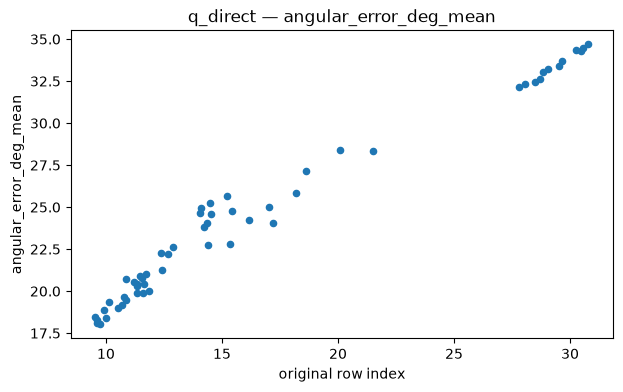

In [10]:
model_name = "q_direct"

plot_df = (
    df_stats.loc[df_stats["model"] == model_name]
    .sort_values(by="angular_error_deg_mean")
    .reset_index()
)

ax = plot_df.plot.scatter(
    x="angular_error_deg_median",
    y="angular_error_deg_mean",
    figsize=(7, 4),
    title=f"{model_name} — angular_error_deg_mean"
)

ax.set_xlabel("original row index")
ax.set_ylabel("angular_error_deg_mean")

In [11]:
df_stats.describe()

,density,lambda_tva,learning_rate,n_iter,batch_size,angular_error_deg_mean,angular_error_deg_median,angular_error_deg_p25,angular_error_deg_p75,angular_error_deg_p95,activation_observed_rmse_mean,final_loss,train_time_seconds,train_time_minutes
count,165.000000,1.650000e+02,1.650000e+02,165.000000,165.0,165.000000,165.000000,165.000000,165.000000,165.000000,165.000000,165.000000,165.000000,165.000000
mean,18.036364,2.182039e-06,1.000000e-03,123636.363636,32.0,24.787372,17.238181,6.783589,37.113922,73.124841,0.041760,0.000011,568.958287,9.482638
std,8.128459,4.142571e-06,2.175005e-19,55645.775475,0.0,5.475707,7.141062,3.439380,9.129384,4.995563,0.013168,0.000006,32.241714,0.537362
min,8.000000,0.000000e+00,1.000000e-03,50000.000000,32.0,15.954648,8.361105,3.449122,19.580475,61.650265,0.020812,0.000003,536.085998,8.934767
25%,8.000000,0.000000e+00,1.000000e-03,50000.000000,32.0,20.741388,11.738354,4.424775,30.587814,69.365181,0.031845,0.000006,548.834699,9.147245
50%,16.000000,1.000000e-11,1.000000e-03,100000.000000,32.0,23.648947,14.494495,5.244085,36.197140,73.235497,0.038487,0.000009,568.799842,9.479997
75%,24.000000,1.000000e-09,1.000000e-03,150000.000000,32.0,28.407852,20.439352,7.186926,44.878113,77.485092,0.057076,0.000015,576.765009,9.612750
max,32.000000,1.000000e-05,1.000000e-03,200000.000000,32.0,34.925354,30.793716,13.863643,54.201637,82.016708,0.079715,0.000028,896.275316,14.937922


In [12]:
df_metrics[df_metrics["density"] == 32].columns

Index(['density', 'lambda_tva', 'learning_rate', 'n_iter', 'batch_size',
       'model', 'json_kind', 'json_file', 'path', 'angular_error_deg_mean',
       'angular_error_deg_median', 'angular_error_deg_p25',
       'angular_error_deg_p75', 'angular_error_deg_p95',
       'angular_error_deg_max', 'activation_observed_rmse_by_map',
       'activation_observed_rmse_by_map_0',
       'activation_observed_rmse_by_map_1',
       'activation_observed_rmse_by_map_2',
       'activation_observed_rmse_by_map_3',
       'activation_observed_rmse_by_map_4', 'activation_observed_rmse_mean',
       'final_loss', 'final_loss_data', 'final_loss_pde',
       'final_loss_regu_orient', 'final_loss_regu_orient_weighted',
       'train_time_seconds', 'train_time_minutes', 'train_iters_requested',
       'train_iters_completed', 'checkpoint_dir', 'checkpoint_resumed',
       'checkpoint_resumed_from_iter'],
      dtype='str')

In [13]:
def plot_error_histogram(
    df,
    error_col="angular_error_deg_mean",
    lambda_tvas=None,
    density=None,
    model=None,
    learning_rate=None,
    bins=20,
    figsize=None,
    sharex=True,
    sharey=False,
):
    """
    Plot histograms of an error metric, optionally filtered by lambda_tva,
    density, model, and learning_rate.

    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame containing the experiment results.
        Expected columns include:
        - 'lambda_tva'
        - error_col, e.g. 'angular_error_deg_mean'

    error_col : str
        Column containing the error values to plot.

    lambda_tvas : None, float, int, or list
        Lambda TVA values to include.
        If None, all available lambda_tva values are used.

    density : None, int, or list
        Optional density filter.

    model : None, str, or list
        Optional model filter, e.g. "alpha", "q_alpha", "q_direct".

    learning_rate : None, float, or list
        Optional learning rate filter.

    bins : int
        Number of histogram bins.

    figsize : tuple or None
        Figure size. If None, chosen automatically.

    sharex, sharey : bool
        Whether subplots share x/y axes.

    Returns
    -------
    fig, axes : matplotlib Figure and axes
    """

    required_cols = ["lambda_tva", error_col]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    data = df.copy()

    def _as_list(x):
        if x is None:
            return None
        if isinstance(x, (list, tuple, set, np.ndarray, pd.Series)):
            return list(x)
        return [x]

    def _filter_exact_or_close(data, col, values):
        values = _as_list(values)
        if values is None:
            return data

        mask = np.zeros(len(data), dtype=bool)

        for v in values:
            if pd.api.types.is_numeric_dtype(data[col]):
                mask |= np.isclose(data[col].astype(float), float(v), rtol=1e-12, atol=1e-15)
            else:
                mask |= data[col].eq(v)

        return data.loc[mask].copy()

    # General optional filters
    if density is not None:
        data = data[data["density"].isin(_as_list(density))]

    if model is not None:
        data = data[data["model"].isin(_as_list(model))]

    if learning_rate is not None:
        data = _filter_exact_or_close(data, "learning_rate", learning_rate)

    # If lambda_tvas is None, use every available option
    if lambda_tvas is None:
        lambda_tvas = sorted(data["lambda_tva"].dropna().unique())
    else:
        lambda_tvas = _as_list(lambda_tvas)

    data = _filter_exact_or_close(data, "lambda_tva", lambda_tvas)

    if data.empty:
        raise ValueError("No data left after applying the filters.")

    n_lambdas = len(lambda_tvas)

    if figsize is None:
        figsize = (6, 3.5 * n_lambdas)

    fig, axes = plt.subplots(
        n_lambdas,
        1,
        figsize=figsize,
        sharex=sharex,
        sharey=sharey,
        squeeze=False,
    )

    axes = axes.ravel()

    for ax, lam in zip(axes, lambda_tvas):
        sub = data[np.isclose(data["lambda_tva"].astype(float), float(lam), rtol=1e-12, atol=1e-15)]
        values = sub[error_col].dropna()

        ax.hist(values, bins=bins, edgecolor="black", alpha=0.75)

        ax.set_title(
            f"Histogram of {error_col} | lambda_tva = {lam:g} | n = {len(values)}"
        )
        ax.set_xlabel(error_col)
        ax.set_ylabel("Frequency")
        ax.grid(True, alpha=0.3)

    fig.tight_layout()
    return fig, axes

(<Figure size 600x700 with 2 Axes>,
 array([<Axes: title={'center': 'Histogram of angular_error_deg_mean | lambda_tva = 0 | n = 3'}, xlabel='angular_error_deg_mean', ylabel='Frequency'>,
        <Axes: title={'center': 'Histogram of angular_error_deg_mean | lambda_tva = 1e-11 | n = 3'}, xlabel='angular_error_deg_mean', ylabel='Frequency'>],
       dtype=object))

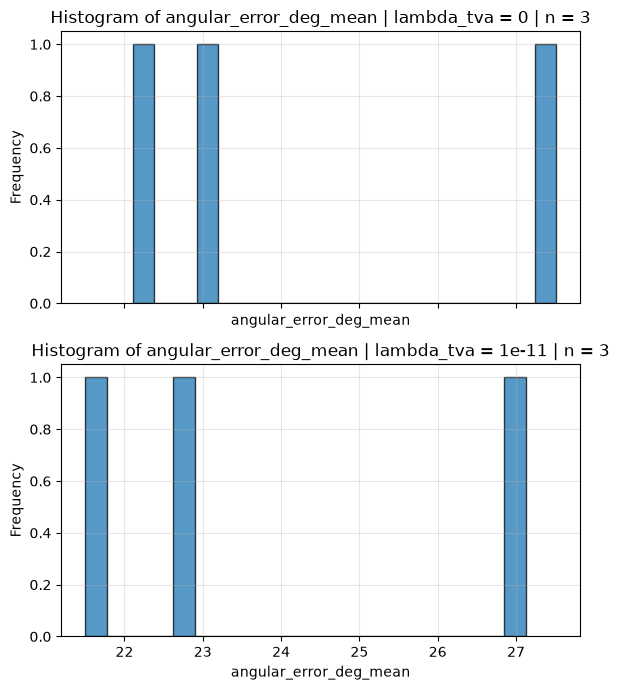

In [14]:
plot_error_histogram(
    df_metrics,
    error_col="angular_error_deg_mean",
    model="q_alpha",
    density=32,
)

(<Figure size 600x1400 with 4 Axes>,
 array([<Axes: title={'center': 'Histogram of angular_error_deg_mean | lambda_tva = 0 | n = 16'}, xlabel='angular_error_deg_mean', ylabel='Frequency'>,
        <Axes: title={'center': 'Histogram of angular_error_deg_mean | lambda_tva = 1e-11 | n = 15'}, xlabel='angular_error_deg_mean', ylabel='Frequency'>,
        <Axes: title={'center': 'Histogram of angular_error_deg_mean | lambda_tva = 1e-09 | n = 12'}, xlabel='angular_error_deg_mean', ylabel='Frequency'>,
        <Axes: title={'center': 'Histogram of angular_error_deg_mean | lambda_tva = 1e-05 | n = 12'}, xlabel='angular_error_deg_mean', ylabel='Frequency'>],
       dtype=object))

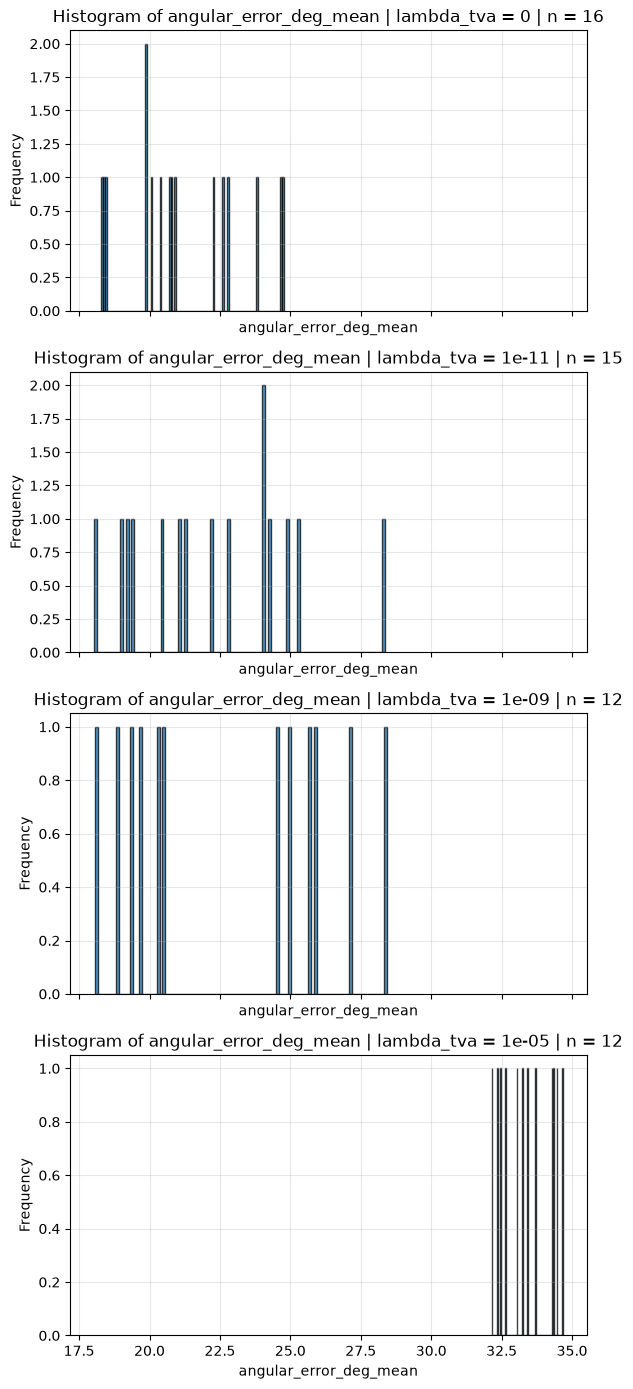

In [15]:
# Filter by model and density
plot_error_histogram(
    df_metrics,
    model="q_direct",
    bins=100
)